eigen_vals [0.44310406 4.55569857]
eigen_vecs [[ 0.63544517 -0.77214599]
 [-0.77214599 -0.63544517]]


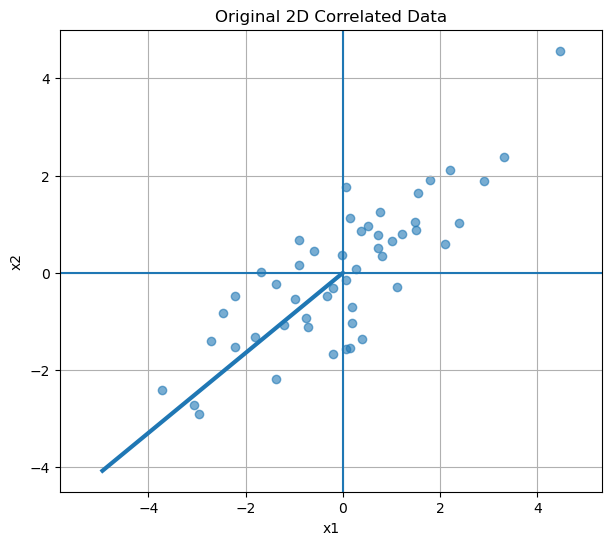

original_variance 4.998802627388136
projected_variance 4.555698565187936
PC1 component retained 91.13579600497809 % of variance


/tmp/ipykernel_5216/2299640570.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


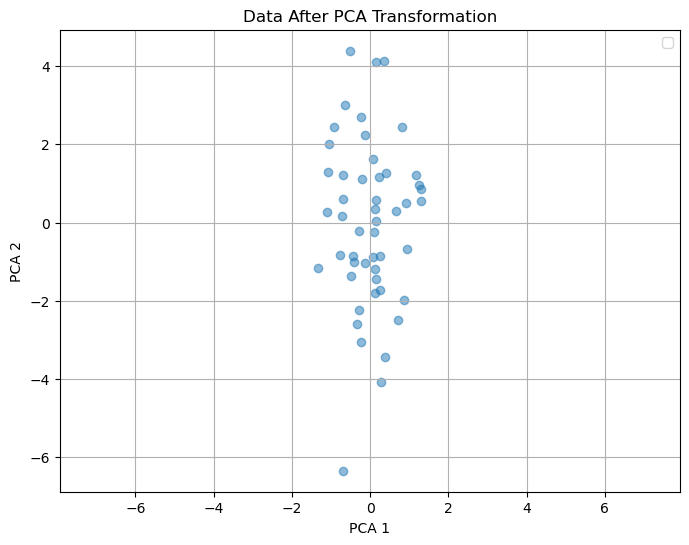

In [43]:
# Assignment 1: Geometry of PCA  

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

mean = [0, 0]
cov = [[4, 3],
       [3, 3]]

x= np.random.multivariate_normal(mean, cov, 50)
x_centered = x - np.mean(x, axis=0)
cov_matrix = np.cov(x_centered, rowvar=False)
eigen_vals,eigen_vecs = np.linalg.eigh(cov_matrix)
print("eigen_vals", eigen_vals)
print("eigen_vecs", eigen_vecs)
picked_vec = eigen_vecs[:, 1]
# print(picked_vec)


plt.figure(figsize=(7, 6))
plt.scatter(x_centered[:, 0], x_centered[:, 1],  alpha=0.6)
plt.axhline(0)
plt.axvline(0)
plt.title("Original 2D Correlated Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(True)

vec = picked_vec * np.sqrt(eigen_vals[1]) * 3

plt.plot([0, vec[0]], [0, vec[1]], linewidth=3, label=f"PC1 Direction")
plt.show()



projected_data = x_centered @ picked_vec

original_variance = np.trace(cov_matrix)
projected_variance = np.var(projected_data, ddof=1)

print("original_variance", original_variance)
print("projected_variance", projected_variance)
print("PC1 component retained {} % of variance".format((projected_variance/original_variance) * 100))


x_pca = x_centered @ eigen_vecs
# Plot original data and principal components
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], alpha=0.5)
plt.axis('equal')
plt.title("Data After PCA Transformation")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()



# This means that projecting the data onto the first principal component(eigen vector with highest eigen value) preserves about 91% of the total variance.

[0.2314939  2.22040282]
[[-9.99999999e-01  3.92009945e-05]
 [ 3.92009945e-05  9.99999999e-01]]
Original variance 2.4518967146375523
Variance (less eigen values' vector direction) 0.2314938991548968
Variance (high eigen values' vector direction) 2.2204028154826547


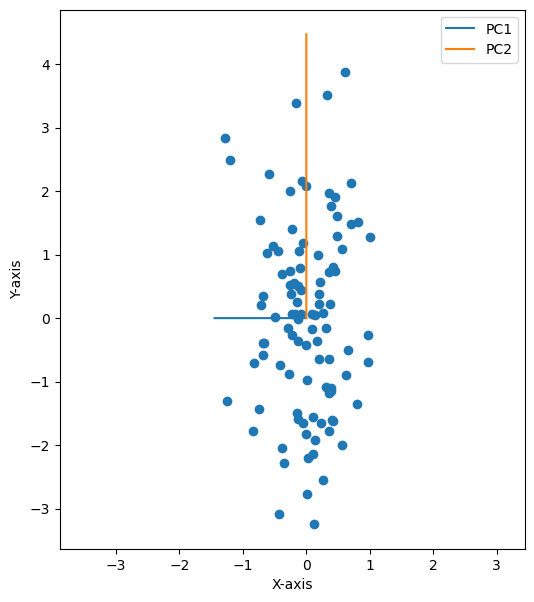

In [83]:
# Assignment 2: Eigenvalues = Variance

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

mean = [0, 0]

x = np.dot(np.random.randn(2, 2), np.random.randn(2, 100)).T
x_centered = x - np.mean(x, axis=0)

cov_matrix = np.cov(x_centered, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
print(eig_vals)
print(eig_vecs)


less_eigen_vec = eig_vecs[0]
high_eigen_vec = eig_vecs[1]

projected_data1 = x_centered @ less_eigen_vec
projected_data2 = x_centered @ high_eigen_vec

print("Original variance", np.trace(cov_matrix))
print("Variance (less eigen values' vector direction)", np.var(projected_data1, ddof=1))
print("Variance (high eigen values' vector direction)", np.var(projected_data2, ddof=1))

# Graph
plt.figure(figsize=(6, 7))
plt.scatter(x_centered[:, 0], x_centered[:, 1])

for i in range(len(eig_vecs)):
    vec = eig_vecs[i] * np.sqrt(eig_vals[i]) * 3
    plt.plot([0, vec[0]], [0, vec[1]], label=f"PC{i+1}")
plt.axis('equal')
plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()